# Calculo do coef kappa entre os llms SRL1


Comparativo entre os diversos LLMs, vamos analisar os resultados de varabilidade das simulações de cada modelo entre modelos.

In [2]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score
import google.generativeai as genai
import openai
import numpy as np
import time
import os
from dotenv import load_dotenv, find_dotenv
from tqdm import tqdm
import matplotlib.pyplot as plt
from irrCAC.raw import CAC

In [3]:
### style de execução
tqdm.pandas()

### variaveis de ambiente e conexões

In [4]:
# Carrega as variáveis do arquivo .env
load_dotenv("/data/codigos/.env")

True

In [5]:
for key in os.environ.keys():
    print(f'{key}')

HOSTNAME
HOME
GPG_KEY
PYTHON_SHA256
PATH
LANG
SHELL
PYTHON_VERSION
PWD
VSCODE_CWD
VSCODE_NLS_CONFIG
VSCODE_HANDLES_SIGPIPE
VSCODE_ESM_ENTRYPOINT
VSCODE_HANDLES_UNCAUGHT_ERRORS
REMOTE_CONTAINERS_IPC
REMOTE_CONTAINERS_SOCKETS
SHLVL
_
REMOTE_CONTAINERS
BROWSER
ELECTRON_RUN_AS_NODE
VSCODE_IPC_HOOK_CLI
APPLICATION_INSIGHTS_NO_STATSBEAT
VSCODE_L10N_BUNDLE_LOCATION
PYDEVD_IPYTHON_COMPATIBLE_DEBUGGING
PYTHONUNBUFFERED
PYTHONIOENCODING
PYTHON_FROZEN_MODULES
PYDEVD_USE_FRAME_EVAL
TERM
CLICOLOR
FORCE_COLOR
CLICOLOR_FORCE
PAGER
GIT_PAGER
MPLBACKEND
KMP_DUPLICATE_LIB_OK
KMP_INIT_AT_FORK
OPENAI_API_KEY_GOV_ANALITICA
GOOGLE_API_KEY_LLMS_PROF_DANILO
ANTROPIC_API_KEY_LLMS
TOGETHER_API_KEY_LLMS
GOOGLE_CLOUD_PROJECT
GOOGLE_CLOUD_REGION


## Carregamento dos datasets

### 1. Datasets

In [6]:
dicto_datasets = {"datasets":["df_result_gpt3", "df_result_gpt4","df_result_gpt41",
                              "df_result_gemini_15_flash","df_result_gemini_pro","df_result_gemini_20_flash",
                              "df_result_claude_haiku_3","df_result_claude_haiku_35","df_result_claude_sonnet_35",
                              "df_result_llama_33_70b","df_result_llama_32_3b","df_result_llama_4_scout_17b"],
                    "caminhos":["/data/codigos/dados/resultados/reproducao_resultados_openai_gpt_35_slr1_v2.csv",
                                "/data/codigos/dados/resultados/reproducao_resultados_openai_gpt_4o_slr1_v2.csv",
                                "/data/codigos/dados/resultados/reproducao_resultados_openai_gpt_41_slr1_v2.csv",
                                "/data/codigos/dados/resultados/reproducao_resultados_gemini_15_flash_slr1_v2.csv",
                                "/data/codigos/dados/resultados/reproducao_resultados_gemini_pro_slr1_v2.csv",
                                "/data/codigos/dados/resultados/reproducao_resultados_gemini_20_flash_slr1_v2.csv",
                                "/data/codigos/dados/resultados/reproducao_resultados_claude_haiku_3_slr1_v2.csv",
                                "/data/codigos/dados/resultados/reproducao_resultados_claude_haiku_35_slr1_v2.csv",
                                "/data/codigos/dados/resultados/reproducao_resultados_claude_sonnet_35_slr1_v2.csv",
                                "/data/codigos/dados/resultados/reproducao_resultados_Llama-3.3-70B-Instruct-Turbo-Free_slr1_v2.csv",
                                "/data/codigos/dados/resultados/reproducao_resultados_Llama-3.2-3B-Instruct-Turbo _slr1_v2.csv",
                                "/data/codigos/dados/resultados/reproducao_resultados_Llama-4-Scout-17B-16E-Instruct_slr1_v2.csv"],
                    "model":["gpt-3.5-turbo", "gpt-4o","gpt-4.1", "gemini-1.5-flash", "gemini-2.5-flash", 
                             "gemini-2.0-flash","claude-3-haiku-20240307","claude-3-5-haiku-20241022",
                             "claude-3-5-sonnet-20241022","Llama-3.3-70B-Instruct-Turbo-Free",
                             "Llama-3.2-3B-Instruct-Turbo","Llama-4-Scout-17B-16E-Instruct"]}

In [9]:
def load_datasets(dicto_datasets):
    for dataset in dicto_datasets["datasets"]:
        globals()[dataset] = pd.read_csv(dicto_datasets["caminhos"][dicto_datasets["datasets"].index(dataset)])
        globals()[dataset]["model"]=dicto_datasets["model"][dicto_datasets["datasets"].index(dataset)]
        
        print(f"{dataset} carregado com sucesso")
    

In [10]:
load_datasets(dicto_datasets)

df_result_gpt3 carregado com sucesso
df_result_gpt4 carregado com sucesso
df_result_gpt41 carregado com sucesso
df_result_gemini_15_flash carregado com sucesso
df_result_gemini_pro carregado com sucesso
df_result_gemini_20_flash carregado com sucesso
df_result_claude_haiku_3 carregado com sucesso
df_result_claude_haiku_35 carregado com sucesso
df_result_claude_sonnet_35 carregado com sucesso
df_result_llama_33_70b carregado com sucesso
df_result_llama_32_3b carregado com sucesso
df_result_llama_4_scout_17b carregado com sucesso


In [11]:
df_result_gpt3.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,gpt-3.5-turbo_IC1_0,gpt-3.5-turbo_IC1_1,gpt-3.5-turbo_IC1_2,gpt-3.5-turbo_IC1_3,gpt-3.5-turbo_IC1_4,gpt-3.5-turbo_IC2_0,gpt-3.5-turbo_IC2_1,gpt-3.5-turbo_IC2_2,gpt-3.5-turbo_IC2_3,gpt-3.5-turbo_IC2_4,model
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não,não estruturado,4,4,7,7,7,6,7,7,6,7,gpt-3.5-turbo
1,slr1_2,Sentiment analysis on arabic tweets: Challeng...,Sentiment analysis and opinion mining are desi...,"Twitter, Sentiment analysis, Opinion mining, N...",sucesso,sucesso,não,não estruturado,4,4,4,4,4,6,6,6,6,6,gpt-3.5-turbo


In [12]:
# Criando uma funcao que devolve duas listas com os nomes das colunas IC1 e IC2
def get_ic_columns(df):
    cols_ic1 = df.filter(regex=r'_\s*IC1_\d+$').columns.tolist()
    cols_ic2 = df.filter(regex=r'_\s*IC2_\d+$').columns.tolist()
    return cols_ic1, cols_ic2

In [13]:
cols_ic1, cols_ic2 = get_ic_columns(df_result_gpt3)

In [14]:
cols_ic1

['gpt-3.5-turbo_IC1_0',
 'gpt-3.5-turbo_IC1_1',
 'gpt-3.5-turbo_IC1_2',
 'gpt-3.5-turbo_IC1_3',
 'gpt-3.5-turbo_IC1_4']

In [15]:
cols_ic2

['gpt-3.5-turbo_IC2_0',
 'gpt-3.5-turbo_IC2_1',
 'gpt-3.5-turbo_IC2_2',
 'gpt-3.5-turbo_IC2_3',
 'gpt-3.5-turbo_IC2_4']

In [26]:
def calculate_gwet_ac2_final(df):
    """
    Calcula Gwet's AC2 com acesso correto às chaves.
    
    Chaves disponíveis em results['est']:
    - coefficient_value: O valor AC2
    - confidence_interval: Tupla (lower, upper)
    - p_value: p-value do teste
    - se: Standard Error
    - pa: Concordância observada (Percent Agreement)
    - pe: Concordância esperada
    - z: Estatística z
    
    Returns:
    --------
    dict com AC2, IC, p-value, SE
    """
    
    if isinstance(df, np.ndarray):
        df = pd.DataFrame(df)
    
    df = df.dropna(how='all').dropna(axis=1, how='all')
    
    try:
        cac = CAC(df)
        results = cac.gwet()
        
        return {
            'ac2': float(results['est']['coefficient_value']),
            'ci_lower': float(results['est']['confidence_interval'][0]),
            'ci_upper': float(results['est']['confidence_interval'][1]),
            'p_value': float(results['est']['p_value']),
            'se': float(results['est']['se']),  # CHAVE CORRETA: 'se'
            'pa': float(results['est']['pa']),  # Percent Agreement (concordância observada)
            'pe': float(results['est']['pe']),  # Percent Expected (concordância esperada)
            'z': float(results['est']['z']),
            'status': 'sucesso'
        }
    except Exception as e:
        print(f"Erro: {type(e).__name__}: {e}")
        return {
            'ac2': np.nan,
            'ci_lower': np.nan,
            'ci_upper': np.nan,
            'p_value': np.nan,
            'se': np.nan,
            'pa': np.nan,
            'pe': np.nan,
            'z': np.nan,
            'status': f'erro: {str(e)}'
        }


In [27]:
result1 = calculate_gwet_ac2_final(df_result_gpt3[cols_ic1])
result2 = calculate_gwet_ac2_final(df_result_gpt3[cols_ic2])

In [28]:
result1

{'ac2': 0.84269,
 'ci_lower': 0.79445,
 'ci_upper': 0.89093,
 'p_value': 0.0,
 'se': 0.02437,
 'pa': 0.86825,
 'pe': 0.1625,
 'z': 34.57499,
 'status': 'sucesso'}

In [33]:
def processa_ac2(lista_dfs):

    # lista os modelos
    
    df_resultados = pd.DataFrame()
    for df in lista_dfs:       
        modelo = df['model'].iloc[0]
        print(f'Processando modelo: {modelo}')       
            # Obtém as colunas IC1 e IC2
        cols_ic1, cols_ic2 = get_ic_columns(df)
        result_ic1 = calculate_gwet_ac2_final(df[cols_ic1])
        result_ic2 = calculate_gwet_ac2_final(df[cols_ic2])

        df_aux = pd.DataFrame({
            'model': [modelo],
            'ac2_ic1': [result_ic1['ac2']],
            'ci_lower_ic1': [result_ic1['ci_lower']],
            'ci_upper_ic1': [result_ic1['ci_upper']],
            'ac2_ic2': [result_ic2['ac2']],
            'ci_lower_ic2': [result_ic2['ci_lower']],
            'ci_upper_ic2': [result_ic2['ci_upper']],
        })

        df_resultados = pd.concat([df_resultados, df_aux], ignore_index=True)

    return df_resultados

In [34]:
# Empilha os datasets para visualização
lista_dfs = [df_result_gpt3,
            df_result_gpt4,
            df_result_gpt41,
            df_result_gemini_15_flash, 
            df_result_gemini_pro, 
            df_result_gemini_20_flash,
            df_result_claude_haiku_3,
            df_result_claude_haiku_35,
            df_result_claude_sonnet_35,
            df_result_llama_33_70b,
            df_result_llama_32_3b,
            df_result_llama_4_scout_17b]

In [35]:
df_resultados = processa_ac2(lista_dfs)
df_resultados

Processando modelo: gpt-3.5-turbo
Processando modelo: gpt-4o
Processando modelo: gpt-4.1
Processando modelo: gemini-1.5-flash
Processando modelo: gemini-2.5-flash
Processando modelo: gemini-2.0-flash
Processando modelo: claude-3-haiku-20240307
Processando modelo: claude-3-5-haiku-20241022
Processando modelo: claude-3-5-sonnet-20241022
Processando modelo: Llama-3.3-70B-Instruct-Turbo-Free
Processando modelo: Llama-3.2-3B-Instruct-Turbo
Processando modelo: Llama-4-Scout-17B-16E-Instruct


,model,ac2_ic1,ci_lower_ic1,ci_upper_ic1,ac2_ic2,ci_lower_ic2,ci_upper_ic2
0,gpt-3.5-turbo,0.84269,0.79445,0.89093,0.82080,0.76908,0.87252
1,gpt-4o,0.87833,0.83373,0.92293,0.79442,0.74563,0.84321
2,gpt-4.1,0.90651,0.86899,0.94403,0.84480,0.79822,0.89137
3,gemini-1.5-flash,0.89049,0.84781,0.93316,0.84697,0.79905,0.89490
4,gemini-2.5-flash,0.90725,0.86263,0.95187,0.69244,0.62345,0.76143
5,gemini-2.0-flash,0.93528,0.90184,0.96872,0.91380,0.87749,0.95011
6,claude-3-haiku-20240307,0.99107,0.97831,1.00000,0.97927,0.95874,0.99979
7,claude-3-5-haiku-20241022,0.98734,0.97264,1.00000,0.96207,0.93728,0.98686
8,claude-3-5-sonnet-20241022,0.99637,0.98917,1.00000,0.98357,0.96494,1.00000
9,Llama-3.3-70B-Instruct-Turbo-Free,1.00000,1.00000,1.00000,0.98867,0.97286,1.00000


## algumas analises

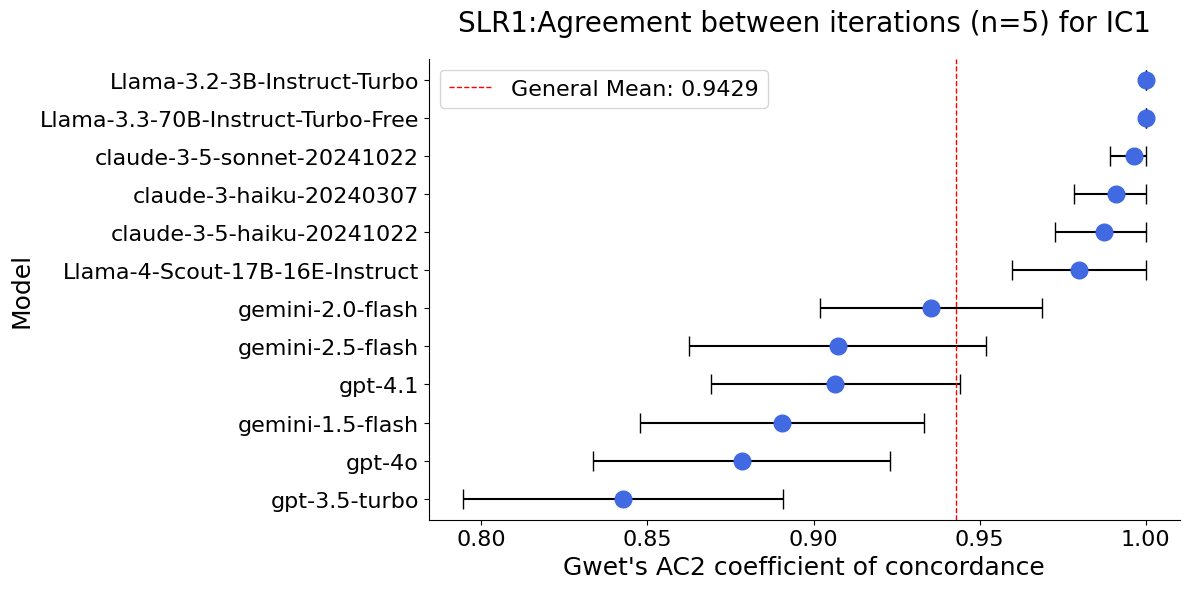

In [38]:
# Ordena o DataFrame em ordem decrescente de accuracy média
df_estatisticas_family = df_resultados.sort_values(by='ac2_ic1', ascending=True)

# Cria o gráfico de fatores de influência com modelo na vertical e accuracy na horizontal
fig, ax = plt.subplots()
fig.set_size_inches(12, 6)

# Plota os pontos centrais (médias) e as barras de erro (limites inferior e superior)
ax.errorbar(df_estatisticas_family['ac2_ic1'], df_estatisticas_family['model'], 
            xerr=[df_estatisticas_family['ac2_ic1'] - df_estatisticas_family['ci_lower_ic1'], 
                  df_estatisticas_family['ci_upper_ic1'] - df_estatisticas_family['ac2_ic1']], 
            fmt='o', color='royalblue', ecolor='black', capsize=7, markersize=12)

# Calcula a média das médias
media_das_medias = df_estatisticas_family['ac2_ic1'].mean()

# Traça a linha horizontal representando a média das médias
ax.axvline(media_das_medias, color='red', linestyle='--', linewidth=1, label=f'General Mean: {media_das_medias:.4f}')

# Ajusta o título e os rótulos
plt.title("SLR1:Agreement between iterations (n=5) for IC1", pad=20, fontsize=20)
plt.ylabel('Model', fontsize=18)
plt.xlabel("Gwet's AC2 coefficient of concordance", fontsize=18)
plt.legend(fontsize=16)

# Remover bordas desnecessárias
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=16)
# Exibe o gráfico
plt.tight_layout()
plt.savefig('/data/codigos/dados/resultados/figuras/slr1_fase_1_comparativo_familia_horizontal_concordancia_ic1.png', 
            dpi=300, bbox_inches='tight')
plt.show()

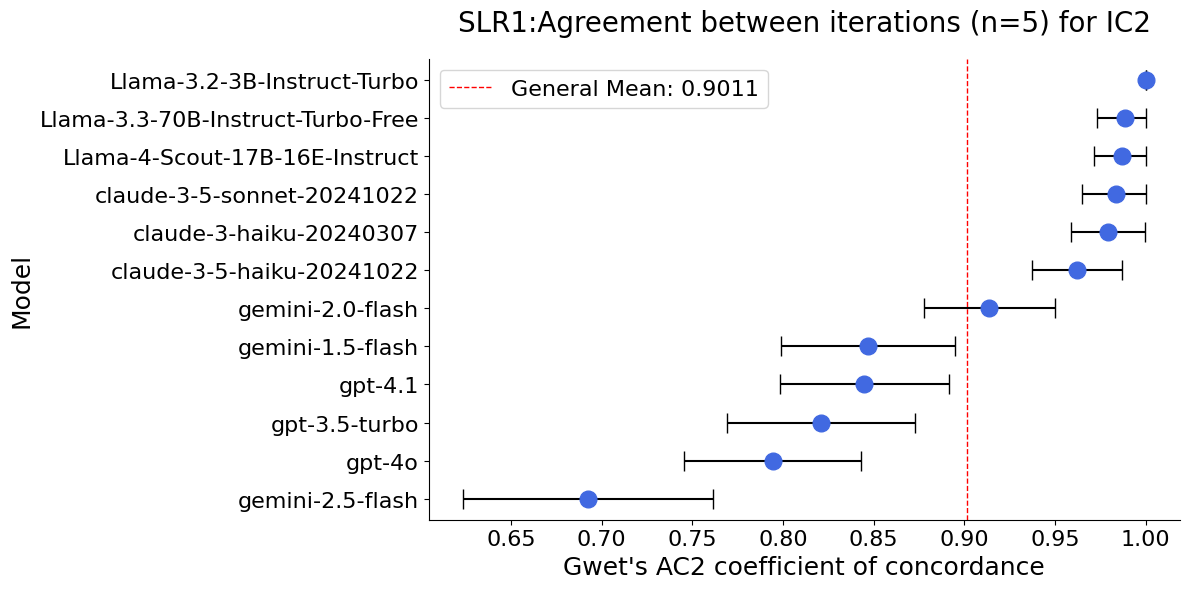

In [39]:
# Ordena o DataFrame em ordem decrescente de accuracy média
df_estatisticas_family = df_resultados.sort_values(by='ac2_ic2', ascending=True)

# Cria o gráfico de fatores de influência com modelo na vertical e accuracy na horizontal
fig, ax = plt.subplots()
fig.set_size_inches(12, 6)

# Plota os pontos centrais (médias) e as barras de erro (limites inferior e superior)
ax.errorbar(df_estatisticas_family['ac2_ic2'], df_estatisticas_family['model'], 
            xerr=[df_estatisticas_family['ac2_ic2'] - df_estatisticas_family['ci_lower_ic2'], 
                  df_estatisticas_family['ci_upper_ic2'] - df_estatisticas_family['ac2_ic2']], 
            fmt='o', color='royalblue', ecolor='black', capsize=7, markersize=12)

# Calcula a média das médias
media_das_medias = df_estatisticas_family['ac2_ic2'].mean()

# Traça a linha horizontal representando a média das médias
ax.axvline(media_das_medias, color='red', linestyle='--', linewidth=1, label=f'General Mean: {media_das_medias:.4f}')

# Ajusta o título e os rótulos
plt.title("SLR1:Agreement between iterations (n=5) for IC2", pad=20, fontsize=20)
plt.ylabel('Model', fontsize=18)
plt.xlabel("Gwet's AC2 coefficient of concordance", fontsize=18)
plt.legend(fontsize=16)

# Remover bordas desnecessárias
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=16)
# Exibe o gráfico
plt.tight_layout()
plt.savefig('/data/codigos/dados/resultados/figuras/slr1_fase_1_comparativo_familia_horizontal_concordancia_ic2.png', 
            dpi=300, bbox_inches='tight')
plt.show()